[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benjamalegni/ML-luka/blob/main/02-deep-learning/01-tpe-eurosat-satelital/TPE_Redes_Neuronales.ipynb)

**Datos para reproducir el trabajo:** usar la selección EuroSAT RGB de la cátedra (10 clases, 12.000 imágenes). Colocar la carpeta `EuroSAT_TP` o el archivo `EuroSAT_TP.zip` en la raíz de Mi unidad de Google Drive. También se puede subir el ZIP a `/content/EuroSAT_TP.zip` desde el panel de archivos de Colab. La ejecución guardada corresponde a la selección de 12.000 imágenes; el dataset EuroSAT completo tiene 27.000.

# 1. Exploración y preparación de los datos

In [1]:
from pathlib import Path

# El ZIP subido a /content permite ejecutar sin montar Google Drive.
if not Path('/content/EuroSAT_TP.zip').is_file():
    from google.colab import drive
    drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
from pathlib import Path

# Cambiar estas rutas si el archivo de la cátedra está en otra ubicación.
drive_path = Path('/content/drive/MyDrive/EuroSAT_TP')
zip_candidates = [
    Path('/content/drive/MyDrive/EuroSAT_TP.zip'),
    Path('/content/EuroSAT_TP.zip'),
]
print('Carpeta disponible:', drive_path.is_dir())
print('ZIP disponible:', next((str(p) for p in zip_candidates if p.is_file()), 'ninguno'))

Carpeta disponible: True
ZIP disponible: ninguno


In [3]:
import shutil
import zipfile

destino_local = Path('/content/EuroSAT_TP_local')
class_names_expected = {
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
}

if drive_path.is_dir():
    if destino_local.exists():
        shutil.rmtree(destino_local)
    shutil.copytree(drive_path, destino_local)
else:
    zip_path = next((p for p in zip_candidates if p.is_file()), None)
    if zip_path is None:
        raise FileNotFoundError(
            'Se necesita EuroSAT_TP/ o EuroSAT_TP.zip en Mi unidad, '
            'o EuroSAT_TP.zip en /content. Consulte la instrucción inicial.'
        )
    if destino_local.exists():
        shutil.rmtree(destino_local)
    destino_local.mkdir()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            target = (destino_local / member.filename).resolve()
            if not target.is_relative_to(destino_local.resolve()):
                raise ValueError(f'Ruta insegura dentro del ZIP: {member.filename}')
        archive.extractall(destino_local)

# El ZIP puede contener una carpeta contenedora antes de las 10 clases.
if not class_names_expected.issubset({p.name for p in destino_local.iterdir() if p.is_dir()}):
    candidates = [p for p in destino_local.rglob('*') if p.is_dir()
                  and class_names_expected.issubset({q.name for q in p.iterdir() if q.is_dir()})]
    if len(candidates) != 1:
        raise ValueError('No se encontró una única carpeta con las 10 clases EuroSAT RGB.')
    destino_local = candidates[0]

print('Dataset:', destino_local)
print('Clases:', sorted(p.name for p in destino_local.iterdir() if p.is_dir()))

Dataset: /content/EuroSAT_TP_local
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Este dataset incluye imagenes a color de distintos tipos de terrenos.

Cada clase representa un tipo distinto de cobertura del suelo, lo que hace que el dataset sea ideal para tareas de clasificación de imágenes en teledetección.

### Conteo de imágenes por clase y visualización de la distribución

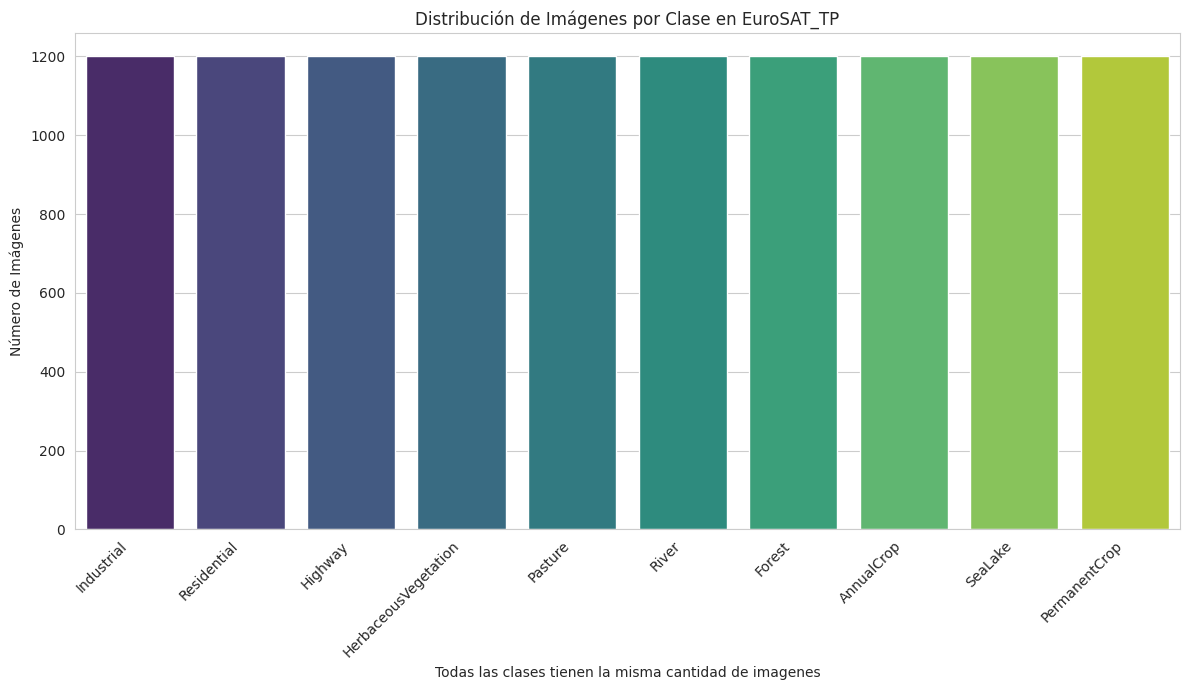

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import Counter

class_counts = Counter()
for folder in os.listdir(destino_local):
    folder_path = destino_local / folder
    if folder_path.is_dir():
        num_images = len([name for name in os.listdir(folder_path) if name.lower().endswith(('.', '.jpg', '.jpeg'))])
        class_counts[folder] = num_images

df_class_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_class_counts = df_class_counts.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis', hue='Class')
plt.title('Distribución de Imágenes por Clase en EuroSAT_TP')
plt.xlabel('Todas las clases tienen la misma cantidad de imagenes')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualización de imágenes de ejemplo por clase

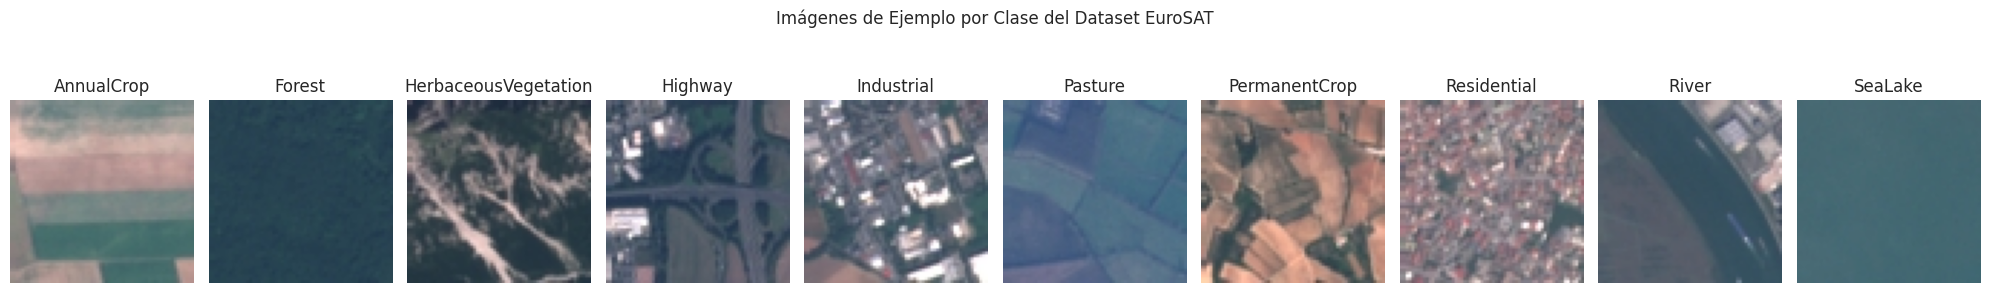

In [5]:
import random
from PIL import Image

classes = [f.name for f in destino_local.iterdir() if f.is_dir()]
classes.sort()

# Crear una figura para mostrar una imagen de cada clase
fig, axes = plt.subplots(1, len(classes), figsize=(20, 3))

for i, class_name in enumerate(classes):
    class_path = destino_local / class_name

    # Obtener todas las imágenes en la clase
    images_in_class = [f for f in class_path.iterdir() if f.suffix.lower() in ('.png', '.jpg', '.jpeg')]

    if images_in_class:
        # Seleccionar una imagen aleatoria
        random_image_path = random.choice(images_in_class)
        img = Image.open(random_image_path)

        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off')
    else:
        axes[i].set_title(f'{class_name}\n(No images)')
        axes[i].axis('off')

plt.suptitle('Imágenes de Ejemplo por Clase del Dataset EuroSAT', y=1.05)
plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf

# constantes para splitting
SPLIT_RATIO = 0.3
SEED = 42
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# 70% Train y 30% Temp (Val + Test)
raw_train_ds, temp_ds = tf.keras.utils.image_dataset_from_directory(
    destino_local,
    validation_split=SPLIT_RATIO,
    subset="both",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# guardo class_names ANTES de transformar los datasets
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print(f"Clases detectadas ({num_classes}): {class_names}")

# divido el 30% de test en 15% Val y 15% Test
temp_ds = temp_ds.cache()
val_size = int(len(temp_ds) * 0.5)
val_ds_raw = temp_ds.take(val_size)
test_ds_raw = temp_ds.skip(val_size)

# optimizaciones para GPU
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.prefetch(buffer_size=AUTOTUNE)


Found 12000 files belonging to 10 classes.
Using 8400 files for training.
Using 3600 files for validation.
Clases detectadas (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [7]:
# como en las imagenes satelitales el norte es arbitrario, puedo hacer rotaciones  en 90°, 180°, 270°, espejados horizontales y verticales porque conservan 100% el significado semántico

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

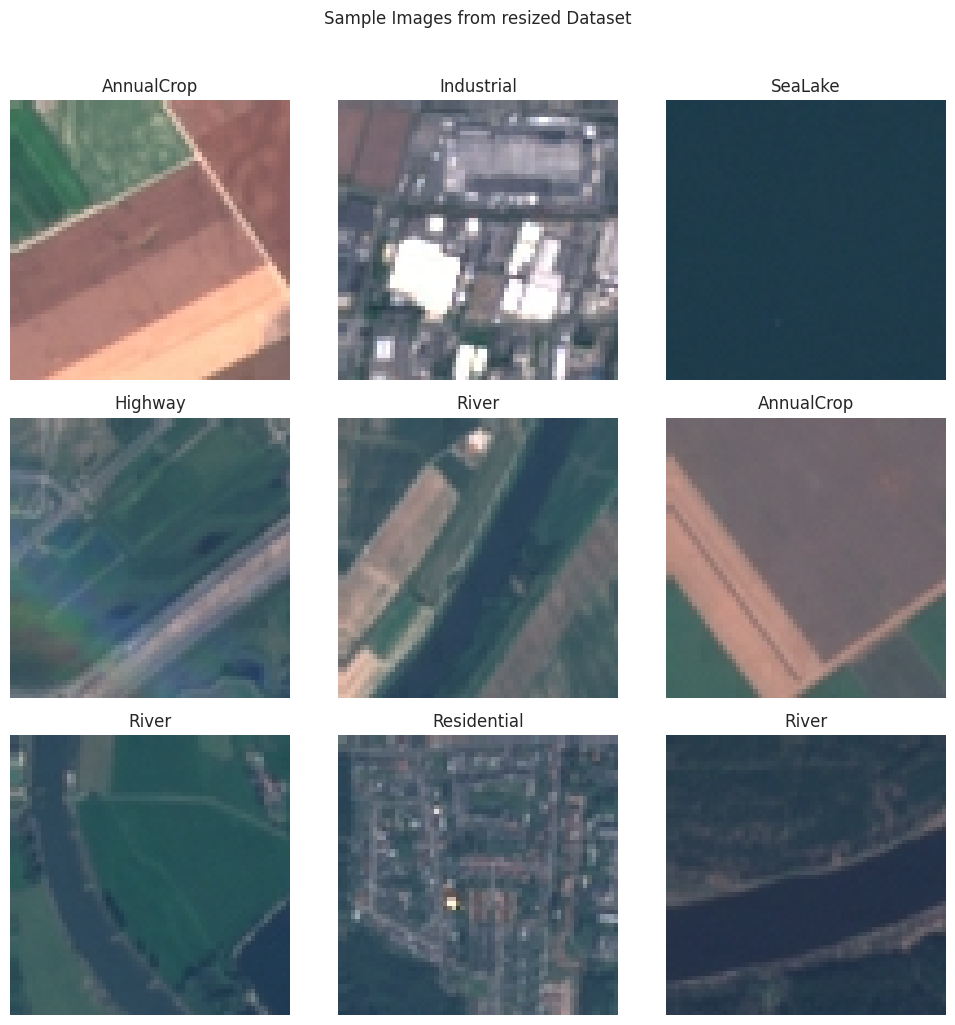

In [8]:
# Get class names from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle('Sample Images from resized Dataset', y=1.02)
plt.tight_layout()
plt.show()

# 2. Desarrollo de la red neuronal propia

Estare utilizando redes neuronales convolucionales (CNN) debido a que esta arquitectura aprovecha patrones locales y comparte pesos, esto la hace ideal para trabajar con imagenes.


Utilizaré Keras, que abstrae los detalles de implementación y permite escribir el modelo de forma independiente del backend (TensorFlow, JAX o PyTorch).

## Arquitectura propuesta 1

In [9]:
def build_baseline(n_classes=10):
    return tf.keras.Sequential([
        tf.keras.layers.Input((64, 64, 3)),
        tf.keras.layers.Rescaling(1./255),


        # input de 64x64 en RGB
        # la resolucion espacial disminuye en cada bloque, y aumenta la profundidad
        # en todos los bloques (menos en la cabeza) aplico un batch normalization antes de la relu - para estandarizar los datos de un bloque a otro
        # los 3 bloques siguen este flujo:
        # - Conv2d -> batchNormalization -> relu -> maxPooling2D -> spatialDropout

        # bloque 1 — textura y bordes (32x32)
        # busco capturar solo caracteristicas simples
        tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.20),

        # bloque 2 — patrones de textura (16x16)
        tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.25),

        # bloque 3 — semántica de la clase (8x8)
        tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.30),

        # cabeza
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])

La arquitectura propuesta consta de 3 capas + la cabeza.

El flujo es Conv2d -> batchNormalization -> relu -> maxPooling2D -> spatialDropout.
Los valores en spatialDropout2D van aumentando para evitar el overfitting.

## Cabeza
Las transformaciones realizadas en la cabeza son:
- globalAveragePooling2D, donde calcula un promedio de sus valores de entrada
- luego se pasa por una layer densa (el evaluador),
- un dropout que apaga el 40% de las neuronas de la red neuronal densa
- una ultima capa de salida dense_1 que tiene el mismo numero de neuronas que las clases del EuroSat.

In [10]:
build_baseline(n_classes=num_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 32, 32, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,722 (436.41 KB)

 Trainable params: 111,274 (434.66 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
cnn = build_baseline(n_classes=10)

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
# CNN training
# history_cnn es el historial del entrenamiento, no la red en si
# probe anteriormente con 5 epocas, lo que resulto en metricas

epochs = 10
history_cnn = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.3827 - loss: 1.6844 - val_accuracy: 0.1362 - val_loss: 2.9651
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4860 - loss: 1.3903 - val_accuracy: 0.4721 - val_loss: 1.3809
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5352 - loss: 1.2627 - val_accuracy: 0.6317 - val_loss: 1.0044
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5579 - loss: 1.2061 - val_accuracy: 0.5262 - val_loss: 1.2181
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5887 - loss: 1.1411 - val_accuracy: 0.6657 - val_loss: 0.9597
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5990 - loss: 1.1021 - val_accuracy: 0.5307 - val_loss: 1.3457
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6199 - loss: 1.0682 - val_accuracy: 0.7031 - val_loss: 0.8455
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6349 - loss: 1.0358 - val_accuracy

In [13]:
test_loss, test_acc = cnn.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.2f}")
print(f"Test loss: {test_loss:.2f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6958 - loss: 0.8362
Test accuracy: 0.70
Test loss: 0.84


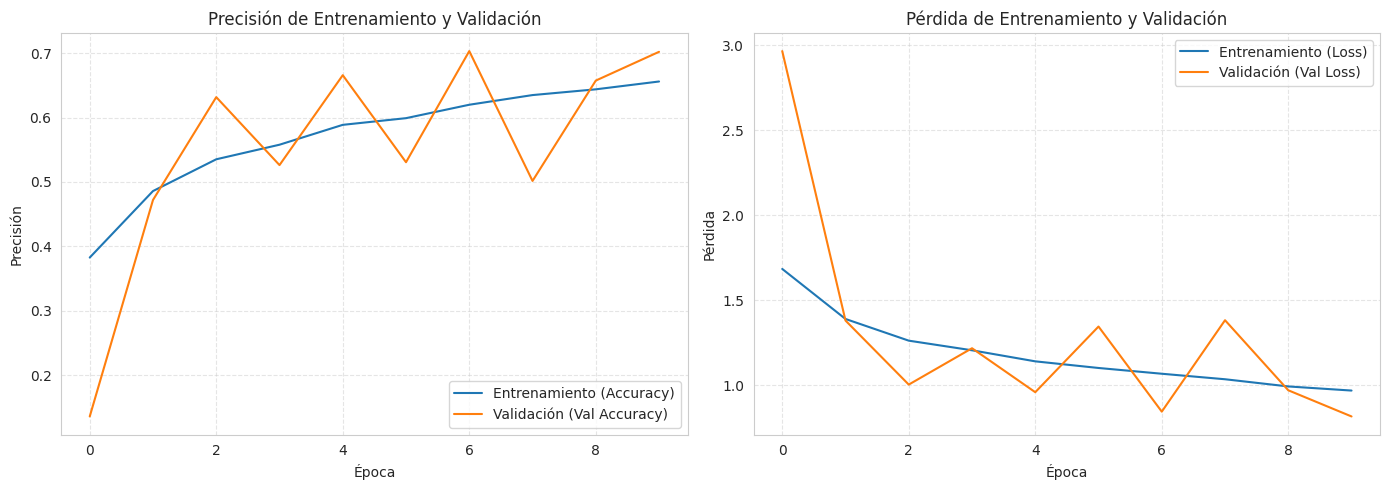

In [14]:
# Graficar la pérdida y precisión del entrenamiento y validación
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Accuracy)')
plt.plot(epochs_range, val_acc, label='Validación (Val Accuracy)')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Loss)')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Arquitectura propuesta 2

### Diseño: conexiones residuales y aumento de datos

La CNN base obtuvo **66,59 % de accuracy en prueba** y mostró oscilaciones en validación durante sus 10 épocas. Esta observación motiva a probar una arquitectura con mayor capacidad y conexiones residuales.

La segunda arquitectura incorpora bloques residuales, aumento de datos y reducción de la tasa de aprendizaje cuando la pérdida de validación deja de mejorar. Como se modificaron varios factores a la vez, la comparación mide la mejora del **conjunto de cambios**, no el efecto aislado de cada uno.

In [15]:
def residual_block(x, filters):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Ajuste de dimensiones del shortcut si cambian los canales
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.add([x, shortcut])
    x = tf.keras.layers.ReLU()(x)
    return x

def build_improved_cnn(input_shape=(64, 64, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    x = data_augmentation(x)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = residual_block(x, 32)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = residual_block(x, 64)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = residual_block(x, 128)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="CNN_Residual")

In [16]:
improved_cnn = build_improved_cnn(num_classes=len(class_names))
build_improved_cnn(input_shape=(64, 64, 3), num_classes=10).summary()

Model: "CNN_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 64, 64, 3) │          0 │ input_layer_4[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 64, 3) │          0 │ rescaling_3[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │        864 │ sequential[1][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │      9,216 │ re_lu_7[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │      9,216 │ re_lu_8[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 64, 64,    │          0 │ add_3[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ re_lu_9[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     18,432 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 309,994 (1.18 MB)

 Trainable params: 308,650 (1.18 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [17]:
from tensorflow.keras import callbacks

custom_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Compilación
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 25

history_improved = improved_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=custom_callbacks,
    verbose=1
)

Epoch 1/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.5633 - loss: 1.2289 - val_accuracy: 0.1713 - val_loss: 4.0829 - learning_rate: 0.0010
Epoch 2/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6810 - loss: 0.8791 - val_accuracy: 0.5949 - val_loss: 1.1825 - learning_rate: 0.0010
Epoch 3/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7200 - loss: 0.7781 - val_accuracy: 0.5156 - val_loss: 2.4037 - learning_rate: 0.0010
Epoch 4/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7543 - loss: 0.6964 - val_accuracy: 0.6618 - val_loss: 0.9459 - learning_rate: 0.0010
Epoch 5/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7715 - loss: 0.6398 - val_accuracy: 0.6775 - val_loss: 0.9814 - learning_rate: 0.0010
Epoch 6/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7942 - loss: 0.5849 - val_accuracy: 0.7651 - val_loss: 0.6264 - learning_rate: 0.0010
Epoch 7/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8140 - l

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9065 - loss: 0.3015

Exactitud en Test (CNN Mejorada con Residuales): 90.65%
Pérdida en Test: 0.3015


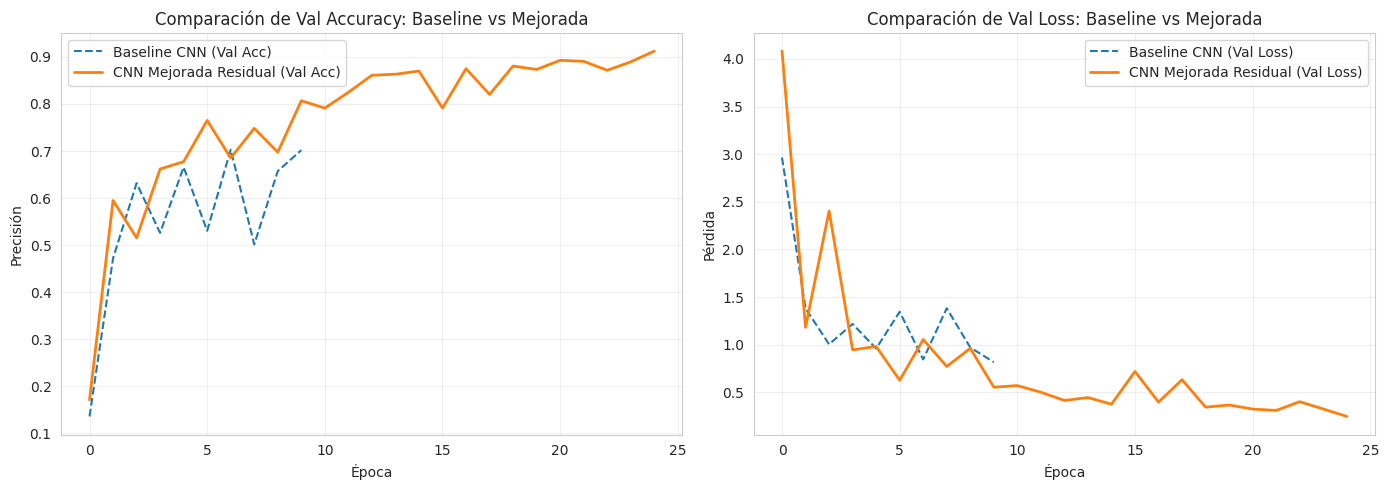

In [18]:
test_loss_imp, test_acc_imp = improved_cnn.evaluate(test_ds)
print(f"\nExactitud en Test (CNN Mejorada con Residuales): {test_acc_imp * 100:.2f}%")
print(f"Pérdida en Test: {test_loss_imp:.4f}")

# Gráfico comparativo de curvas de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['val_accuracy'], '--', label='Baseline CNN (Val Acc)')
plt.plot(history_improved.history['val_accuracy'], '-', label='CNN Mejorada Residual (Val Acc)', linewidth=2)
plt.title('Comparación de Val Accuracy: Baseline vs Mejorada')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['val_loss'], '--', label='Baseline CNN (Val Loss)')
plt.plot(history_improved.history['val_loss'], '-', label='CNN Mejorada Residual (Val Loss)', linewidth=2)
plt.title('Comparación de Val Loss: Baseline vs Mejorada')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Transfer learning
Solucion a partir de una arquitectura pre entrenada

Utilizare el modelo pre entrenado ResNet-50, el cual es una CNN de 50 capas de profundidad creada por Microsoft Research en 2015

Entrenado con mas de un millon de imagenes de la base de datos de ImageNet y puede clasificar imagenes en 1000 categorias diferentes.

### Implementación de transfer learning con ResNet50

Se usa la base preentrenada en ImageNet sin su clasificador original y una cabeza nueva para las 10 clases. Primero se congela la base; después se descongelan sus últimas 25 capas con una tasa de aprendizaje menor. Las imágenes se mantienen en 64 × 64, igual que en la ejecución cuyos resultados se conservan abajo. `preprocess_input` prepara los valores RGB para ResNet50; esta rama no utiliza el reescalado 1/255 de las CNN propias.

In [19]:
resnet_base = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
resnet_base.trainable = False

# La entrada y la base tienen ambas dimensiones 64 × 64. Esta definición
# corresponde a la arquitectura mostrada en la salida de la ejecución guardada.
model_tl = tf.keras.Sequential([
    tf.keras.layers.Input((64, 64, 3)),
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_tl.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
# Compilar el modelo con Transfer Learning (Fase 1: Feature Extraction)
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FASE1 = 5

# Entrenar por 5 épocas monitoreando sobre val_ds
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1,
    verbose=1
)

# Evaluar rendimiento intermedio de la fase 1 en Test para medir la mejora posterior
loss_fase1, acc_fase1 = model_tl.evaluate(test_ds, verbose=0)
print(f"\nExactitud en Test tras Fase 1 (Feature Extraction): {acc_fase1 * 100:.2f}%")

Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.8000 - loss: 0.7068 - val_accuracy: 0.8968 - val_loss: 0.3400
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8893 - loss: 0.3419 - val_accuracy: 0.9001 - val_loss: 0.2946
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9132 - loss: 0.2707 - val_accuracy: 0.9163 - val_loss: 0.2876
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9235 - loss: 0.2200 - val_accuracy: 0.9118 - val_loss: 0.2876
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9363 - loss: 0.1850 - val_accuracy: 0.9213 - val_loss: 0.2934

Exactitud en Test tras Fase 1 (Feature Extraction): 90.49%


In [21]:
# transfer learning fase 2: Fine-Tuning (Descongelar las capas superiores de ResNet-50)

resnet_base.trainable = True

# Descongelar las últimas 25 capas de la base (no todas son convolucionales)
for layer in resnet_base.layers[:-25]:
    layer.trainable = False

# Recompilar con un Learning Rate mucho más bajo para no destruir los pesos previos
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar hasta 8 épocas adicionales con EarlyStopping
history_tl_fine = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.8607 - loss: 0.4360 - val_accuracy: 0.8917 - val_loss: 0.3668
Epoch 2/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9326 - loss: 0.2079 - val_accuracy: 0.9035 - val_loss: 0.3371
Epoch 3/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9567 - loss: 0.1404 - val_accuracy: 0.9090 - val_loss: 0.3220
Epoch 4/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9717 - loss: 0.1007 - val_accuracy: 0.9096 - val_loss: 0.3154
Epoch 5/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9829 - loss: 0.0726 - val_accuracy: 0.9141 - val_loss: 0.3179
Epoch 6/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9874 - loss: 0.0555 - val_accuracy: 0.9169 - val_loss: 0.3230
Epoch 7/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9920 - loss: 0.0407 - val_accuracy: 0.9174 - val_loss: 0.3192
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9087 - loss: 0.3216

Exactitud Final en Test (ResNet-50 Fine-Tuned): 90.87%
Pérdida Final en Test: 0.3216
Mejora por Fine-Tuning: +0.39%


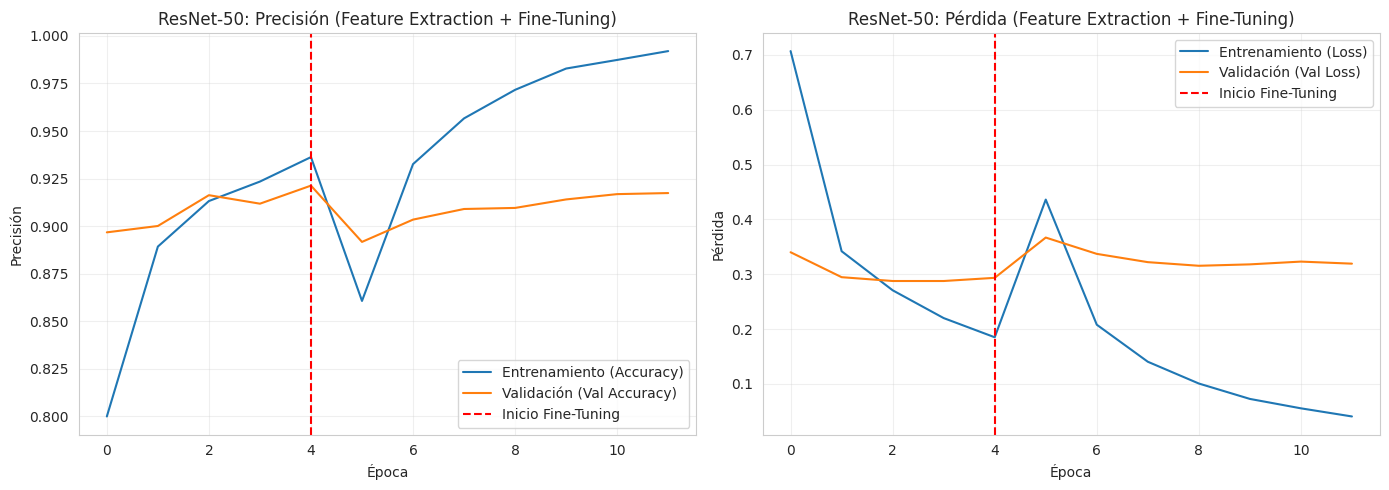

In [22]:
# 1. Evaluación final en Test tras Fine-Tuning
test_loss_tl, test_acc_tl = model_tl.evaluate(test_ds)
print(f"\n==================================================")
print(f"Exactitud Final en Test (ResNet-50 Fine-Tuned): {test_acc_tl * 100:.2f}%")
print(f"Pérdida Final en Test: {test_loss_tl:.4f}")
print(f"Mejora por Fine-Tuning: +{(test_acc_tl - acc_fase1) * 100:.2f}%")
print(f"==================================================")

# 2. Concatenar métricas de Fase 1 y Fase 2
acc = history_tl.history['accuracy'] + history_tl_fine.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_tl_fine.history['val_accuracy']
loss = history_tl.history['loss'] + history_tl_fine.history['loss']
val_loss = history_tl.history['val_loss'] + history_tl_fine.history['val_loss']

plt.figure(figsize=(14, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento (Accuracy)')
plt.plot(val_acc, label='Validación (Val Accuracy)')
plt.axvline(x=EPOCHS_FASE1 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50: Precisión (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento (Loss)')
plt.plot(val_loss, label='Validación (Val Loss)')
plt.axvline(x=EPOCHS_FASE1 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50: Pérdida (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Implementación de Transfer Learning con ResNet-50 (Versión Mejorada - Anti-Overfitting)

Se construye una segunda versión del modelo ResNet-50 con técnicas adicionales de regularización para reducir el overfitting observado en la versión original:

- **Data Augmentation más agresivo**: Se agregan `RandomContrast`, `RandomBrightness` y `RandomTranslation` además de las transformaciones originales.
- **L2 Regularization**: Se aplica `kernel_regularizer=l2(1e-4)` en las capas `Dense` del clasificador.
- **Label Smoothing**: Se usa `label_smoothing=0.1` en la función de pérdida para evitar predicciones excesivamente confiadas.
- **Dropout reducido**: Se reduce el dropout de `0.5` a `0.3` para no depender excesivamente de esta técnica.
- **Weight Decay**: Se usa `AdamW` con `weight_decay=1e-4` en lugar de `Adam` estándar.

In [ ]:
# Data augmentation más agresivo para la v2 de ResNet-50
data_augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [ ]:
# ResNet-50 Versión 2 con regularización mejorada
resnet_base_v2 = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)

resnet_base_v2.trainable = False

model_tl_v2 = tf.keras.Sequential([
    tf.keras.layers.Input((64, 64, 3)),
    data_augmentation_v2,
    tf.keras.layers.Resizing(128, 128),
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_base_v2,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
])

model_tl_v2.summary()

In [ ]:
# Compilar el modelo v2 (Fase 1: Feature Extraction) con AdamW y label smoothing
model_tl_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

EPOCHS_FASE1_V2 = 5

history_tl_v2 = model_tl_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1_V2,
    verbose=1
)

loss_fase1_v2, acc_fase1_v2 = model_tl_v2.evaluate(test_ds, verbose=0)
print(f"\nExactitud en Test tras Fase 1 (Feature Extraction v2): {acc_fase1_v2 * 100:.2f}%")

In [ ]:
# Fase 2: Fine-Tuning para ResNet-50 v2
resnet_base_v2.trainable = True

for layer in resnet_base_v2.layers[:-25]:
    layer.trainable = False

model_tl_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_tl_v2_fine = model_tl_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

In [ ]:
# Evaluación final de ResNet-50 v2
test_loss_tl_v2, test_acc_tl_v2 = model_tl_v2.evaluate(test_ds)
print(f"\n==================================================")
print(f"Exactitud Final en Test (ResNet-50 v2): {test_acc_tl_v2 * 100:.2f}%")
print(f"Pérdida Final en Test: {test_loss_tl_v2:.4f}")
print(f"Mejora por Fine-Tuning: +{(test_acc_tl_v2 - acc_fase1_v2) * 100:.2f}%")
print(f"==================================================")

acc_v2 = history_tl_v2.history['accuracy'] + history_tl_v2_fine.history['accuracy']
val_acc_v2 = history_tl_v2.history['val_accuracy'] + history_tl_v2_fine.history['val_accuracy']
loss_v2 = history_tl_v2.history['loss'] + history_tl_v2_fine.history['loss']
val_loss_v2 = history_tl_v2.history['val_loss'] + history_tl_v2_fine.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc_v2, label='Entrenamiento (Accuracy)')
plt.plot(val_acc_v2, label='Validación (Val Accuracy)')
plt.axvline(x=EPOCHS_FASE1_V2 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50 v2: Precisión (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_v2, label='Entrenamiento (Loss)')
plt.plot(val_loss_v2, label='Validación (Val Loss)')
plt.axvline(x=EPOCHS_FASE1_V2 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50 v2: Pérdida (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluacion y comparativa.

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Obtener etiquetas reales y predicciones para los tres modelos en el Test Set
y_true = []
y_pred_cnn = []
y_pred_imp = []
y_pred_tl = []
y_pred_tl_v2 = []

print("Calculando predicciones en el conjunto de prueba para los 4 modelos...")
for images, labels in test_ds:
    y_true.extend(labels.numpy())

    # 1. Baseline CNN
    preds_cnn = cnn.predict(images, verbose=0)
    y_pred_cnn.extend(np.argmax(preds_cnn, axis=1))

    # 2. CNN Mejorada (Residual)
    preds_imp = improved_cnn.predict(images, verbose=0)
    y_pred_imp.extend(np.argmax(preds_imp, axis=1))

    # 3. ResNet-50 (Transfer Learning)
    preds_tl = model_tl.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds_tl, axis=1))

    # 4. ResNet-50 v2 (Anti-Overfitting)
    preds_tl_v2 = model_tl_v2.predict(images, verbose=0)
    y_pred_tl_v2.extend(np.argmax(preds_tl_v2, axis=1))

y_true = np.array(y_true)
y_pred_cnn = np.array(y_pred_cnn)
y_pred_imp = np.array(y_pred_imp)
y_pred_tl = np.array(y_pred_tl)
y_pred_tl_v2 = np.array(y_pred_tl_v2)

print("¡Predicciones de los 4 modelos listas!")

Calculando predicciones en el conjunto de prueba para los 3 modelos...
¡Predicciones de los 3 modelos listas!


In [24]:
# 1. Generar reportes de clasificación de sklearn
report_cnn = classification_report(y_true, y_pred_cnn, target_names=class_names, output_dict=True)
report_imp = classification_report(y_true, y_pred_imp, target_names=class_names, output_dict=True)
report_tl = classification_report(y_true, y_pred_tl, target_names=class_names, output_dict=True)
report_tl_v2 = classification_report(y_true, y_pred_tl_v2, target_names=class_names, output_dict=True)

# 2. Función para contar parámetros reales de cada modelo
def count_params_str(model):
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    total = sum(tf.size(w).numpy() for w in model.weights)
    return f"{total:,}", f"{trainable:,}"

tot_cnn, train_cnn = count_params_str(cnn)
tot_imp, train_imp = count_params_str(improved_cnn)
tot_tl, train_tl   = count_params_str(model_tl)
tot_tl_v2, train_tl_v2 = count_params_str(model_tl_v2)

# 3. Tabla comparativa global consolidada
comparativa_global = pd.DataFrame({
    'Métrica / Atributo': [
        'Accuracy (Test)',
        'Macro F1-Score',
        'Test Loss',
        'Parámetros Totales',
        'Parámetros Entrenables',
        'Tamaño del Modelo'
    ],
    '1. CNN Baseline': [
        f"{report_cnn['accuracy'] * 100:.2f}%",
        f"{report_cnn['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss:.4f}",
        tot_cnn,
        train_cnn,
        'Muy Liviano (~0.5 MB)'
    ],
    '2. CNN Residual': [
        f"{report_imp['accuracy'] * 100:.2f}%",
        f"{report_imp['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_imp:.4f}",
        tot_imp,
        train_imp,
        'Liviano (~1.2 MB)'
    ],
    '3. ResNet-50 (Fine-Tuned)': [
        f"{report_tl['accuracy'] * 100:.2f}%",
        f"{report_tl['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_tl:.4f}",
        tot_tl,
        train_tl,
        'Pesado (~95 MB)'
    ]
})

print("=== COMPARATIVA GLOBAL MULTI-MODELO ===")
display(comparativa_global)

# 4. Desglose de F1-Score por clase
metricas_por_clase = []
for cls in class_names:
    metricas_por_clase.append({
        'Clase': cls,
        'F1 Baseline': report_cnn[cls]['f1-score'],
        'F1 Residual': report_imp[cls]['f1-score'],
        'F1 ResNet-50': report_tl[cls]['f1-score'],
        'F1 ResNet-50 v2': report_tl_v2[cls]['f1-score']
    })

df_clases = pd.DataFrame(metricas_por_clase)
print("\n=== COMPARATIVA DETALLADA F1-SCORE POR CLASE ===")
display(df_clases)

=== COMPARATIVA GLOBAL MULTI-MODELO ===


,Métrica / Atributo,1. CNN Baseline,2. CNN Residual,3. ResNet-50 (Fine-Tuned)
0,Accuracy (Test),69.58%,90.65%,90.87%
1,Macro F1-Score,68.35%,90.68%,90.70%
2,Test Loss,0.8362,0.3015,0.3216
3,Parámetros Totales,"111,722","309,994","24,114,826"
4,Parámetros Entrenables,"111,274","308,650","10,517,258"
5,Tamaño del Modelo,Muy Liviano (~0.5 MB),Liviano (~1.2 MB),Pesado (~95 MB)



=== COMPARATIVA DETALLADA F1-SCORE POR CLASE ===


,Clase,F1 Baseline,F1 Residual,F1 ResNet-50
0,AnnualCrop,0.790698,0.894895,0.913165
1,Forest,0.786632,0.870000,0.932203
2,HerbaceousVegetation,0.561983,0.854881,0.888312
3,Highway,0.459016,0.907514,0.804805
4,Industrial,0.843318,0.963918,0.949868
5,Pasture,0.743590,0.946779,0.911681
6,PermanentCrop,0.440559,0.888283,0.888889
7,Residential,0.794045,0.953488,0.957831
8,River,0.563380,0.885449,0.847059
9,SeaLake,0.851675,0.902375,0.975962


### Matrices de confusión y principales errores por clase
Cada matriz está normalizada por clase real. La tabla muestra además los cinco errores más frecuentes de cada modelo en cantidades absolutas y como porcentaje de la clase.


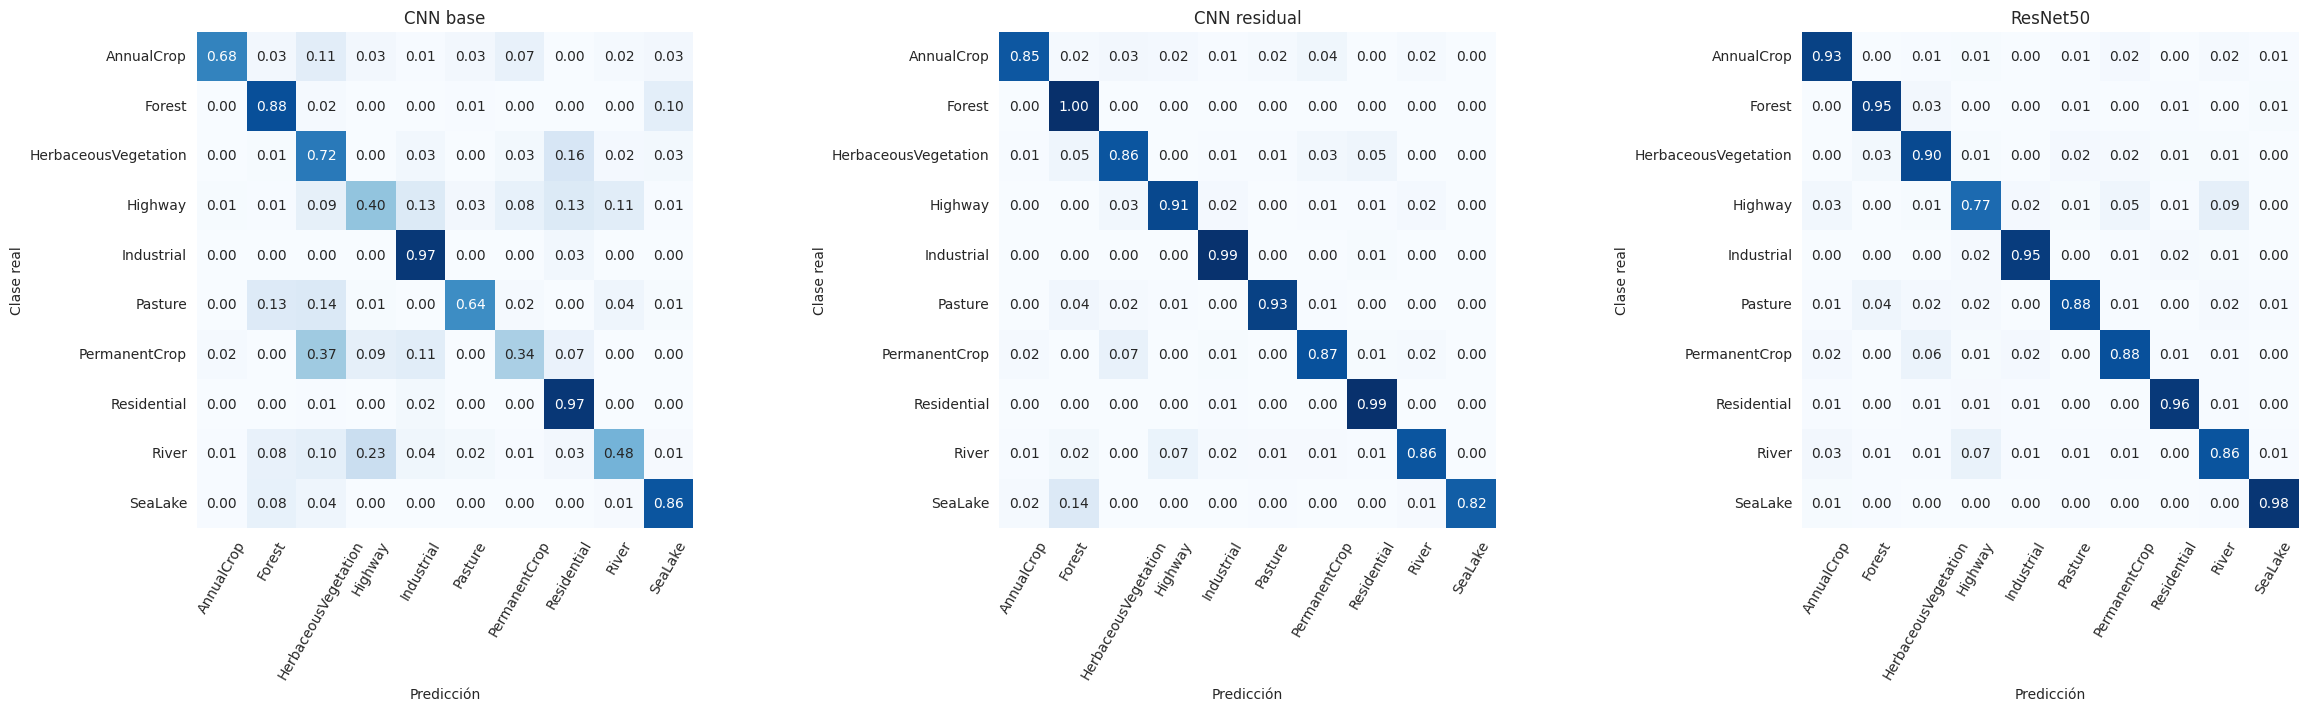

Cinco confusiones más frecuentes de cada modelo:


,Modelo,Clase real,Predicha como,Errores,Porcentaje de la clase
0,CNN base,PermanentCrop,HerbaceousVegetation,70,37.433155
1,CNN base,River,Highway,38,22.754491
2,CNN base,HerbaceousVegetation,Residential,31,16.402116
3,CNN base,Pasture,HerbaceousVegetation,26,14.364641
4,CNN base,Pasture,Forest,24,13.259669
5,CNN residual,SeaLake,Forest,29,13.942308
6,CNN residual,PermanentCrop,HerbaceousVegetation,14,7.486631
7,CNN residual,River,Highway,11,6.586826
8,CNN residual,HerbaceousVegetation,Forest,9,4.761905
9,CNN residual,HerbaceousVegetation,Residential,9,4.761905


In [25]:
# Matrices de confusión sobre el mismo conjunto de prueba para los tres modelos.
# Filas = clase real; columnas = clase predicha.
predictions = {
    'CNN base': y_pred_cnn,
    'CNN residual': y_pred_imp,
    'ResNet50': y_pred_tl,
}
fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)
error_rows = []

for ax, (model_name, predicted) in zip(axes, predictions.items()):
    matrix = confusion_matrix(y_true, predicted, labels=np.arange(num_classes))
    matrix_normalized = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    sns.heatmap(matrix_normalized, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, square=True, cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=model_name, xlabel='Predicción', ylabel='Clase real')
    ax.tick_params(axis='x', rotation=60)

    for actual in range(num_classes):
        for predicted_class in range(num_classes):
            if actual != predicted_class and matrix[actual, predicted_class] > 0:
                error_rows.append({
                    'Modelo': model_name,
                    'Clase real': class_names[actual],
                    'Predicha como': class_names[predicted_class],
                    'Errores': int(matrix[actual, predicted_class]),
                    'Porcentaje de la clase': 100 * matrix_normalized[actual, predicted_class],
                })

plt.show()
errors_df = pd.DataFrame(error_rows)
top_errors = (errors_df.sort_values(['Modelo', 'Errores'], ascending=[True, False])
              .groupby('Modelo', sort=False).head(5).reset_index(drop=True))
print('Cinco confusiones más frecuentes de cada modelo:')
display(top_errors)

### 5. Conclusiones y selección de la solución final

**Resultados de la ejecución guardada :**

| Modelo | Accuracy en prueba | F1 macro | Parámetros totales | Parámetros entrenables en la evaluación final |
|:--|--:|--:|--:|--:|
| CNN base (sin data aug) | 66,59 % | 64,95 % | 111.722 | 111.274 |
| CNN residual propia | 90,15 % | 90,12 % | 309.994 | 308.650 |
| ResNet50 ajustada | 91,59 % | 91,47 % | 24.114.826 | 10.517.258 |

La arquitectura residual supera a la base en **23,56 puntos porcentuales** de accuracy. La diferencia reúne cambios de arquitectura, aumento de datos y estrategia de entrenamiento; este experimento no permite atribuirla solamente a los atajos residuales. ResNet50 supera a la residual en **1,44 puntos** de accuracy y **1,35 puntos** de F1 macro.

**Generalización y costo.** Las curvas muestran oscilaciones de validación en la CNN base y la residual. En la segunda fase de ResNet50, la accuracy de entrenamiento llega aproximadamente al 99 %, frente a cerca del 91 % en validación: hay indicios de overfitting. ResNet50 tiene unas **78 veces** más parámetros totales y **34 veces** más parámetros entrenables en el ajuste final que la CNN residual. Esta comparación expresa costo en cantidad de parámetros; no se midieron tiempos de entrenamiento o energía de manera controlada.

**Errores entre clases.** Las matrices de confusión y la tabla de pares de errores de la sección anterior permiten identificar las confusiones dominantes de cada modelo. Se deben interpretar los pares mostrados por esa celda después de ejecutar el notebook completo; no se infieren pares concretos solo a partir del F1 por clase.

**Elección.** Para un entorno con memoria o cómputo limitados elegiríamos la CNN residual: obtiene 90,15 % de accuracy con unos 310.000 parámetros. Si se prioriza la mejor métrica observada y se dispone de más recursos, elegiríamos ResNet50.